In [8]:
# Kai Gandingco
# COE 311K
# 4 March 2026
# Homework 6

# My steps are a little bit out of order in this notebook,
# but they're all labeled in the comments!

import numpy as np
import matplotlib.pyplot as plt

In [9]:
def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step 2: step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]              # Subdiagonal, A[i] = h_i−1
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal, B[i] = 2 (h_i-1 + h_i)
        C[i - 1] = h[i]                # Superdiagonal, C[i] = h_i
        D[i - 1] = 6 * ( ((y[i+1]-y[i]) / h[i]) - ((y[i]-y[i-1]) / h[i-1]) )             
        # Right-hand side vector

    return A, B, C, D

In [10]:
def thomas_algorithm(a, b, c, d):
    n = len(b)
    for i in range (1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [11]:
# Step 4: Evaluate the spline

def evaluate_spline(x, y, M, xeval):
    n = len(x)
    
    for i in range(n - 1):
        if x[i] <= xeval <= x[i+1]:
            h = x[i+1] - x[i]
            a = y[i]
            b = ((y[i+1] - y[i]) / h) - (h * (2*M[i] + M[i+1]) / 6)
            c = M[i] / 2
            d = (M[i+1] - M[i]) / (6 * h)
            
            xdiff = xeval - x[i]
            polynomial = a + b*xdiff + c*(xdiff**2) + d*(xdiff**3)
            return polynomial
    raise ValueError("xeval outside interpolation range; invalid results")

In [12]:
# Step 1: Custom data points
X = np.array([0, 3, 4, 8, 10])
Y = np.random.randint(0, 10, size=5)
xeval = np.linspace(0, 10, 100)

In [13]:
# Step 3

# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(X, Y)

# Solve the system with the Thomas algorithm
thomasSolution = thomas_algorithm(A.copy(), B.copy(), C.copy(), D.copy())

# Natural boundary conditions
M = np.zeros(len(X))
M[1:-1] = thomasSolution

# Get smooth cubic spline
smoothSpline = np.array([evaluate_spline(X, Y, M, xe) for xe in xeval])

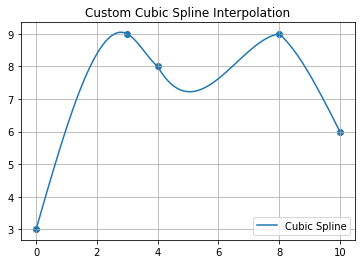

In [14]:
# Output: Plotting
plt.figure()
plt.scatter(X, Y)
plt.plot(xeval, smoothSpline, label="Cubic Spline")
plt.title("Custom Cubic Spline Interpolation")
plt.legend()
plt.grid()
plt.show()